C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

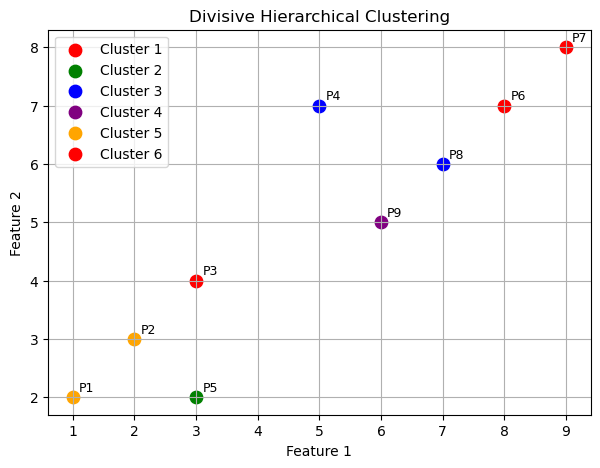

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Sample dataset
X = np.array([
    [1,2],
    [2,3],
    [3,4],
    [5,7],
    [3,2],
    [8,7],
    [9,8],
    [7,6],
    [6,5]
])

# Start with all points in a single cluster
clusters = [X]

# Store final clusters
final_clusters = []

# Maximum number of splits
max_splits = 3

for _ in range(max_splits):

    new_clusters = []

    for cluster in clusters:

        # If cluster is too small, keep it as final
        if len(cluster) <= 2:
            final_clusters.append(cluster)
            continue

        # Apply K-Means to split cluster into two
        kmeans = KMeans(n_clusters=2, random_state=42)
        labels = kmeans.fit_predict(cluster)

        cluster1 = cluster[labels == 0]
        cluster2 = cluster[labels == 1]

        new_clusters.append(cluster1)
        new_clusters.append(cluster2)

    clusters = new_clusters

# Add remaining clusters
final_clusters.extend(clusters)

# Visualization
colors = ['red', 'green', 'blue', 'purple', 'orange']

plt.figure(figsize=(7,5))

for i, cluster in enumerate(final_clusters):

    cluster = np.array(cluster)

    if len(cluster) == 0:
        continue

    plt.scatter(
        cluster[:,0],
        cluster[:,1],
        c=colors[i % len(colors)],
        label=f"Cluster {i+1}",
        s=80
    )

# Label each point
for i, point in enumerate(X):
    plt.text(point[0]+0.1, point[1]+0.1, f"P{i+1}", fontsize=9)

plt.title("Divisive Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

plt.show()